In [1]:
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
# torch.multiprocessing.set_start_method('spawn', force=True)
import time
import importlib
import torch.optim as optim
from torchsummary import summary
import os
import statistics

os.chdir("../")
from src.data_preparation import SimulatedDataset, collate_function, load_real_data
from src.transformers import MiniTransformer
import src.transformers as transformerFunctions
from src.transformers import init_weights_recursive
from src.transformers import print_parameters
from src.transformers import create_custom_mask_pair,create_custom_mask_pred, create_distance_to_end_matrix, create_pairwise_distance_matrix
from src.evaluation import calculate_bench1_loss, calculate_bench2_loss, calculate_repeat_loss, calculate_regression_loss, evaluate_mini_transformer
from src.statistical_testing import statistical_testing, print_p_values, plot_context_predindex_pair_effect, get_context_predindex_pair_effect
import torch.autograd.profiler as profiler
from sklearn.model_selection import KFold
device = torch.device("cpu")

In [2]:
if __name__ == '__main__':

    # Hyperparameters
    # data_str = "ghq_b_sum"
    # data_str = "ghq_sum"
    data_str = "simulation"
    batch_size = 1           # Batch size for loading data
    dk = 1                  # d_k
    dv = 1                  # d_v
    nheads = 2             # number of heads
    ncum = 16                 # number of cumulants
    maxlen = 10             # maximum length of the sequence
    learning_rate = 1e-3
    lambda_l2 = 1e-3
    EPOCHS = 200
    target_sample_size = 7  
    nrepp = 10
    
    # Set the random seed for reproducibility
    seed = 999
    torch.manual_seed(seed)
    
    n = 200
    p = 10
    maxlen = 10
    # Create Dataset and DataLoader
    train_dataset = SimulatedDataset(n, p, maxlen=maxlen, device = device).data
    eval_dataset = SimulatedDataset(1000, p, maxlen=4, device = device).data
    
    predindex = 2
    


    n = len(train_dataset)
    p = train_dataset[0].shape[1]
    print("Sample size: ", len(train_dataset), "\n")
    



    mask_pairwise = create_custom_mask_pair(maxlen, device)
    mask_pred = create_custom_mask_pred(maxlen, device)
    distance_to_end_matrix = create_distance_to_end_matrix(maxlen, device)
    pairwise_distance_matrix = create_pairwise_distance_matrix(maxlen, device)


    dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_function,  num_workers=0)
    
    model = MiniTransformer(p, nheads, dk, dv, ncum, mask_pairwise,mask_pred, pairwise_distance_matrix, distance_to_end_matrix,  device)

    model.apply(init_weights_recursive)
    
    
    print("distance to end par:", model.multiheadattn.distance_to_end_weight.item(), "\n")
    print("distance between pair par:", model.multiheadattn.distance_between_two_positions_weight.item(), "\n")


    model.to(device)

    # model = torch.compile(model)
    # Start the timer
    start_time = time.time()

    # Define optimizer
    optimizer = optim.Adam(model.parameters(), lr= learning_rate, weight_decay=lambda_l2)
    # optimizer = optim.Adam(model.parameters(), lr= learning_rate)
    
    print("Number of Parameters", transformerFunctions.count_parameters(model))
    
    run_path = transformerFunctions.train_mini_transformer(model, dataloader, optimizer, lambda_l2, EPOCHS, device)


    # End the timer
    end_time = time.time()

    # Calculate and print the execution time
    execution_time = end_time - start_time 
    print(f"Execution time: {execution_time:.6f} seconds")



# Evaluate the model
        
    eval_dataloader = DataLoader(eval_dataset, batch_size=1, shuffle=True, collate_fn=collate_function, num_workers=0)
    
    model_loss_predindex, model_loss_total = evaluate_mini_transformer(eval_dataloader, model, predindex)
    
    print("model loss total: ", model_loss_total.item(), "\n") 
    
    print("model loss predindex: ", model_loss_predindex.item(), "\n") 
    
    print("distance to end par:", model.multiheadattn.distance_to_end_weight.item())
    print("distance between pair par:", model.multiheadattn.distance_between_two_positions_weight.item(), "\n")


Sample size:  200 

distance to end par: 0.07354012876749039 

distance between pair par: -0.07123458385467529 

Number of Parameters 270
EPOCH 1:
avg_loss: 15.24998
EPOCH 11:
avg_loss: 9.15318
EPOCH 21:
avg_loss: 9.09479
EPOCH 31:
avg_loss: 9.04142
EPOCH 41:
avg_loss: 9.00733
EPOCH 51:
avg_loss: 8.96600
EPOCH 61:
avg_loss: 8.86757
EPOCH 71:
avg_loss: 8.73564
EPOCH 81:
avg_loss: 8.69814
EPOCH 91:
avg_loss: 8.65991
EPOCH 101:
avg_loss: 8.64440
EPOCH 111:
avg_loss: 8.61622
EPOCH 121:
avg_loss: 8.60637
EPOCH 131:
avg_loss: 8.59192
EPOCH 141:
avg_loss: 8.58289
EPOCH 151:
avg_loss: 8.58873
EPOCH 161:
avg_loss: 8.57492
EPOCH 171:
avg_loss: 8.57780
EPOCH 181:
avg_loss: 8.57015
EPOCH 191:
avg_loss: 8.56610
Execution time: 29.952685 seconds
model loss total:  0.1971142441034317 

model loss predindex:  0.10465342551469803 

distance to end par: 0.2886428236961365
distance between pair par: -0.49942636489868164 



In [3]:

avepval, stdpval, context, targetall = statistical_testing(model, train_dataset, p, predindex, nrepp, target_sample_size)

Repetition 1/10
Repetition 2/10
Repetition 3/10
Repetition 4/10
Repetition 5/10
Repetition 6/10
Repetition 7/10
Repetition 8/10
Repetition 9/10
Repetition 10/10


In [4]:
print_p_values(avepval, stdpval)

Variable 1: 0.0102 ± 0.02
Variable 2: 0.0170 ± 0.01
Variable 3: 0.0000 ± 0.00
Variable 4: 0.8168 ± 0.11
Variable 5: 0.7731 ± 0.13
Variable 6: 0.7366 ± 0.11
Variable 7: 0.4488 ± 0.21
Variable 8: 0.7454 ± 0.10
Variable 9: 0.6917 ± 0.15
Variable 10: 0.7247 ± 0.17


In [5]:
context_predindex_pair_effect = get_context_predindex_pair_effect(model, p, context, targetall, nrepp)    

Repetition 1/10
Repetition 2/10
Repetition 3/10
Repetition 4/10
Repetition 5/10
Repetition 6/10
Repetition 7/10
Repetition 8/10
Repetition 9/10
Repetition 10/10


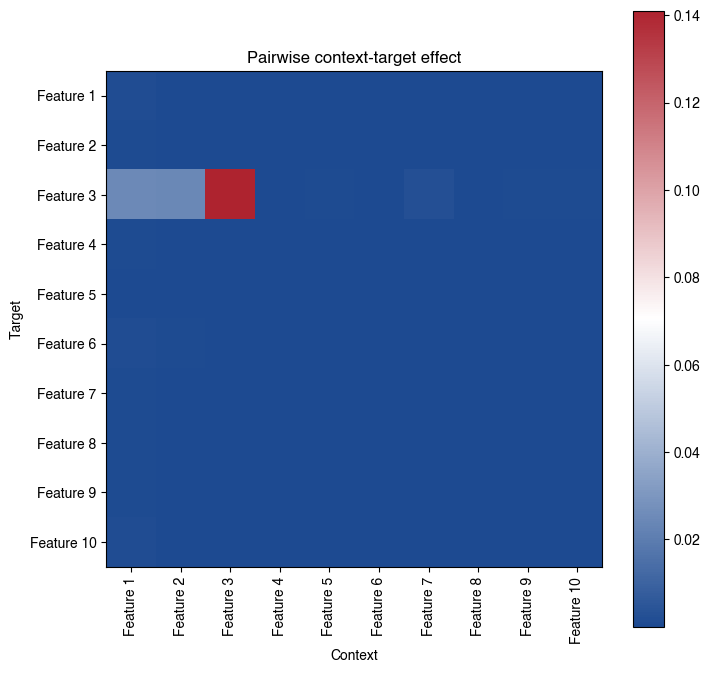

In [6]:
plot = plot_context_predindex_pair_effect(context_predindex_pair_effect, data_str, "./notebooks")

In [7]:
with open(f"./notebooks/statistical_testing/{data_str}_results_n={n}_batch_size={batch_size}_p={p}_ncum={ncum}_nheads={nheads}_epochs={EPOCHS}_seed={seed}.txt", "a") as f:
    f.write(f"For combination sample size: {target_sample_size} \n")
    for i in range(avepval.shape[0]):
        f.write(f"Variable {i+1}: {avepval[i]:.4f} ± {stdpval[i]:.2f}\n")

    